<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [62]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-06-02 12:40:21--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  35.0MB/s    in 5.6s    

2026-06-02 12:40:27 (35.8 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [63]:
!pip install pandas

In [64]:
!pip install matplotlib

In [65]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [75]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [76]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [77]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


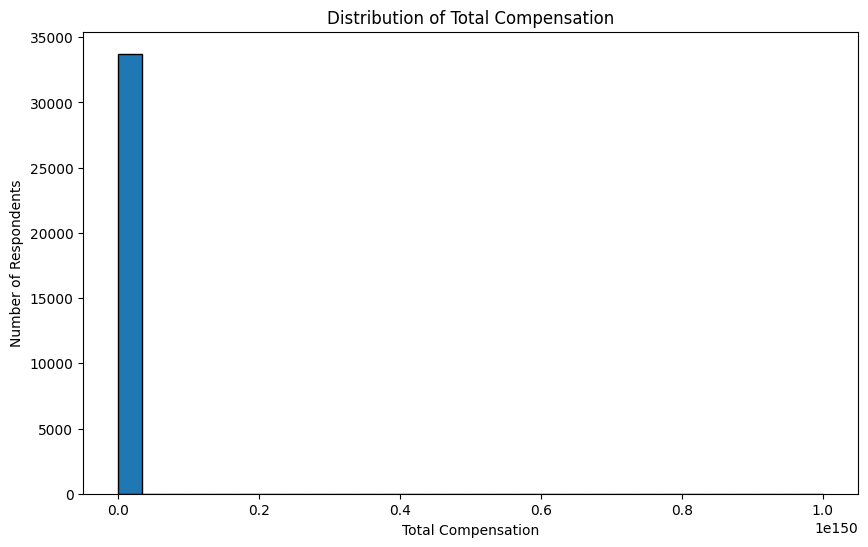

In [78]:
QUERY = """ 
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""

df_compTotal = pd.read_sql_query(QUERY, conn)

comp_data = df_compTotal["CompTotal"].dropna()

comp_data_filtered = comp_data[comp_data <= comp_data.quantile(0.99)]

plt.figure(figsize=(10, 6))
plt.hist(comp_data, bins=30, edgecolor="black")

plt.title("Distribution of Total Compensation")
plt.xlabel("Total Compensation")
plt.ylabel("Number of Respondents")

plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


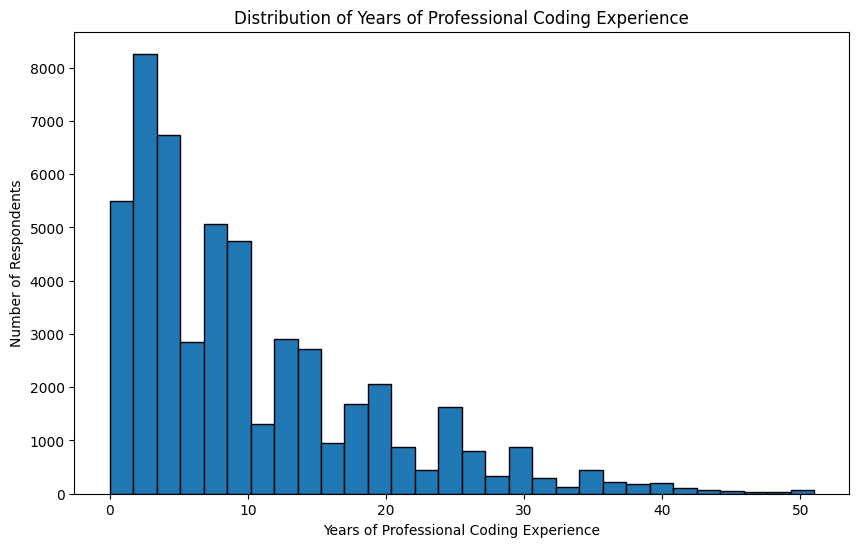

In [70]:
QUERY = """
SELECT YearsCodePro
FROM main
WHERE YearsCodePro IS NOT NULL
"""

df_years = pd.read_sql_query(QUERY, conn)

# Convert YearsCodePro into numbers
df_years["YearsCodePro"] = df_years["YearsCodePro"].replace({
    "Less than 1 year": 0,
    "More than 50 years": 51
})

df_years["YearsCodePro"] = pd.to_numeric(df_years["YearsCodePro"], errors="coerce")

# Remove missing/non-numeric values
years_data = df_years["YearsCodePro"].dropna()

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(years_data, bins=30, edgecolor="black")

plt.title("Distribution of Years of Professional Coding Experience")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Number of Respondents")

plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


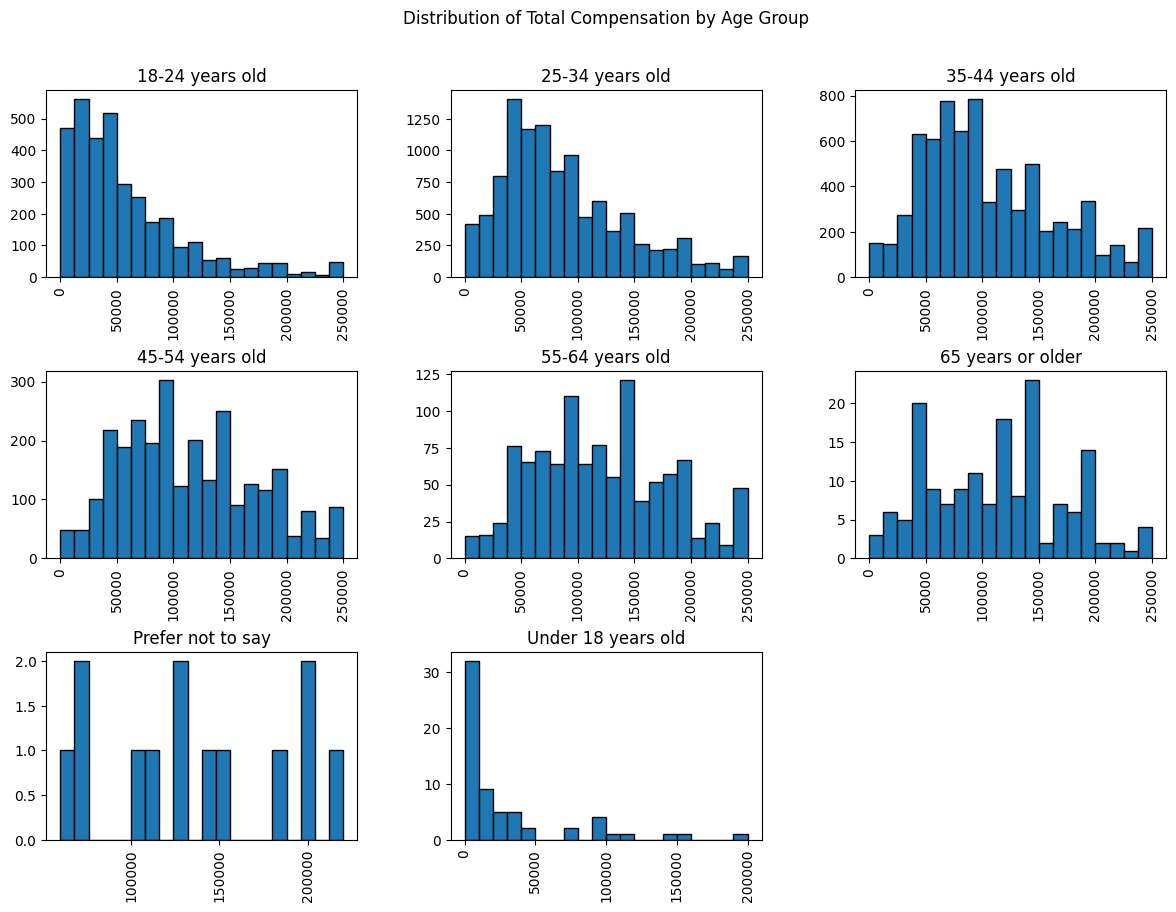

In [71]:
QUERY = """
SELECT CompTotal, Age
FROM main
WHERE CompTotal IS NOT NULL
AND Age IS NOT NULL
"""

df_agecomptotal = pd.read_sql_query(QUERY, conn)

df_comp_age = df_comp_age.dropna(subset=["Age", "CompTotal"])

df_comp_age = df_comp_age[
    (df_comp_age["CompTotal"] > 0) &
    (df_comp_age["CompTotal"] <= 1000000)
]

# Create histograms by age group
df_comp_age.hist(
    column="CompTotal",
    by="Age",
    bins=20,
    figsize=(14, 10),
    edgecolor="black"
)

plt.suptitle("Distribution of Total Compensation by Age Group")
plt.xlabel("Total Compensation")
plt.ylabel("Number of Respondents")

plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


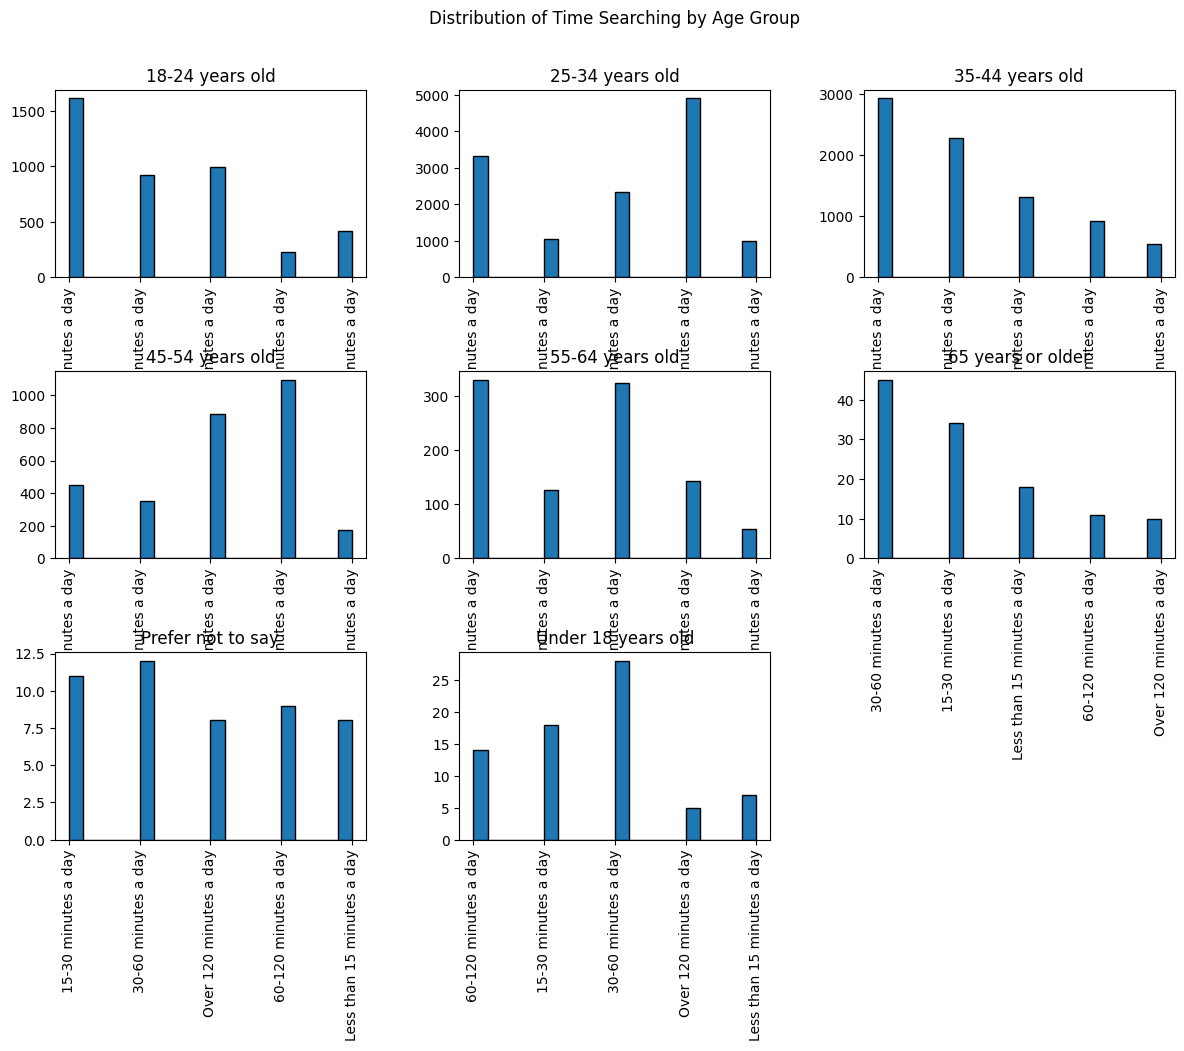

In [72]:
QUERY = """
SELECT TimeSearching, Age
FROM main
WHERE TimeSearching IS NOT NULL
AND Age IS NOT NULL
"""

df_age_timesearching = pd.read_sql_query(QUERY, conn)

df_age_timesearching = df_age_timesearching.dropna(subset=["Age", "TimeSearching"])


# Create histograms by age group
df_age_timesearching.hist(
    column="TimeSearching",
    by="Age",
    bins=20,
    figsize=(14, 10),
    edgecolor="black"
)

plt.suptitle("Distribution of Time Searching by Age Group")
plt.xlabel("Total time")
plt.ylabel("Number of Respondents")

plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


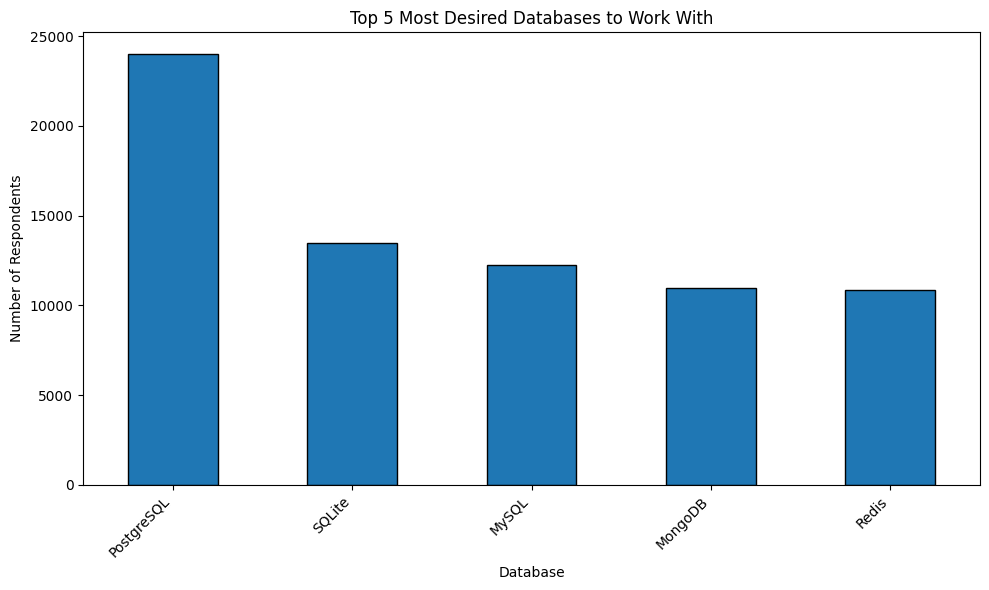

In [73]:
QUERY = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
"""

df_databases = pd.read_sql_query(QUERY, conn)

# Split multiple database answers into separate rows
databases = df_databases["DatabaseWantToWorkWith"].str.split(";").explode()

# Remove missing/blank values
databases = databases.dropna()
databases = databases[databases != ""]

# Get the top 5 most desired databases
top_5_databases = databases.value_counts().head(5)

# Plot bar chart
plt.figure(figsize=(10, 6))
top_5_databases.plot(kind="bar", edgecolor="black")

plt.title("Top 5 Most Desired Databases to Work With")
plt.xlabel("Database")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


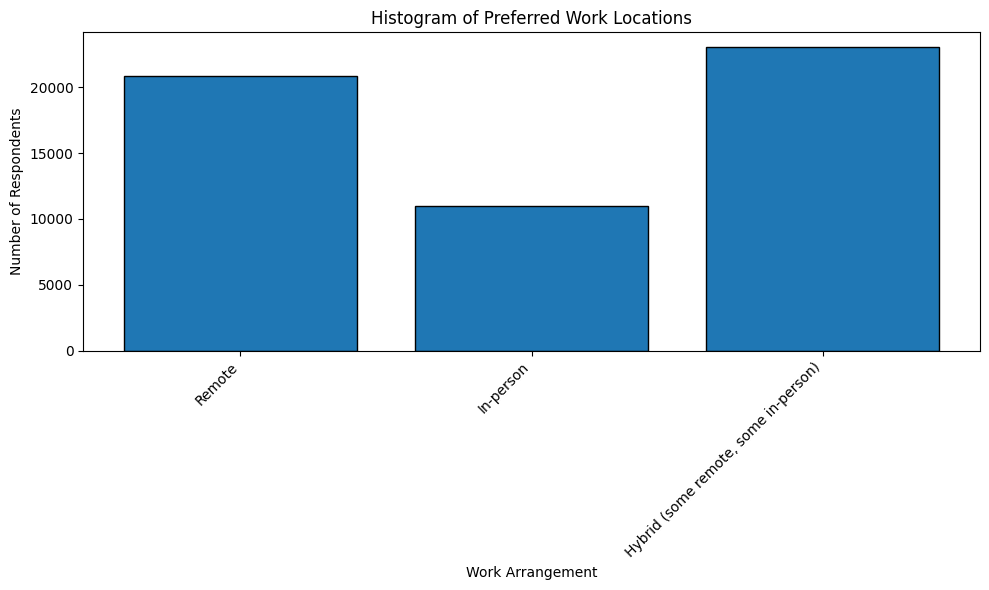

In [80]:

QUERY = """
SELECT RemoteWork
FROM main
WHERE RemoteWork IS NOT NULL
"""

df_remote = pd.read_sql_query(QUERY, conn)

# Convert text categories into numeric codes
remote_codes, remote_labels = pd.factorize(df_remote["RemoteWork"])

# Create bins manually without numpy
bins = [x - 0.5 for x in range(len(remote_labels) + 1)]

plt.figure(figsize=(10, 6))

plt.hist(
    remote_codes,
    bins=bins,
    edgecolor="black",
    rwidth=0.8
)

# Put the original category labels back on the x-axis
plt.xticks(
    range(len(remote_labels)),
    remote_labels,
    rotation=45,
    ha="right"
)

plt.title("Histogram of Preferred Work Locations")
plt.xlabel("Work Arrangement")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


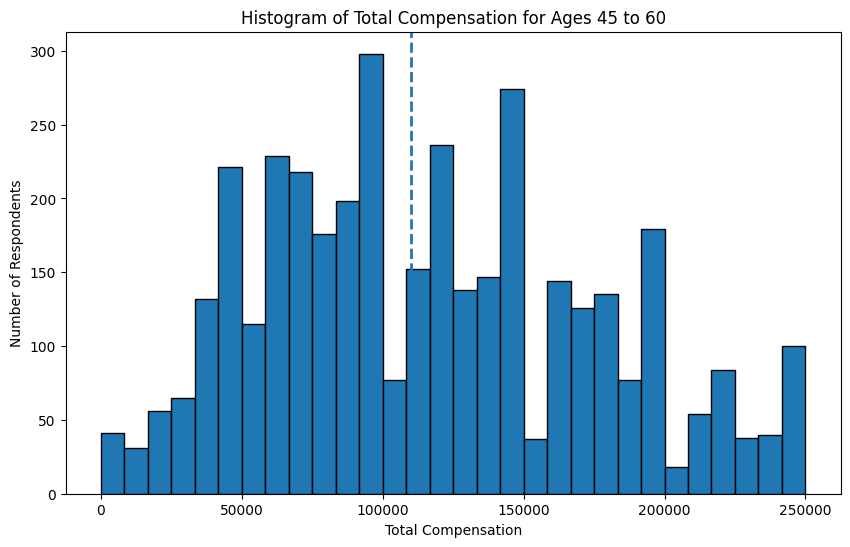

Median CompTotal: 110000.0


In [81]:
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE CompTotal IS NOT NULL
AND Age IN ('45-54 years old', '55-64 years old')
"""

df_age_comp = pd.read_sql_query(QUERY, conn)

# Convert CompTotal to numeric
df_age_comp["CompTotal"] = pd.to_numeric(df_age_comp["CompTotal"], errors="coerce")

# Remove missing values
df_age_comp = df_age_comp.dropna(subset=["CompTotal"])

# Remove unrealistic/extreme values
df_age_comp = df_age_comp[
    (df_age_comp["CompTotal"] > 0) &
    (df_age_comp["CompTotal"] <= 250000)
]

# Calculate median compensation
median_comp = df_age_comp["CompTotal"].median()

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(df_age_comp["CompTotal"], bins=30, edgecolor="black")

# Add median line
plt.axvline(median_comp, linestyle="dashed", linewidth=2)

plt.title("Histogram of Total Compensation for Ages 45 to 60")
plt.xlabel("Total Compensation")
plt.ylabel("Number of Respondents")

plt.show()

print("Median CompTotal:", median_comp)

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


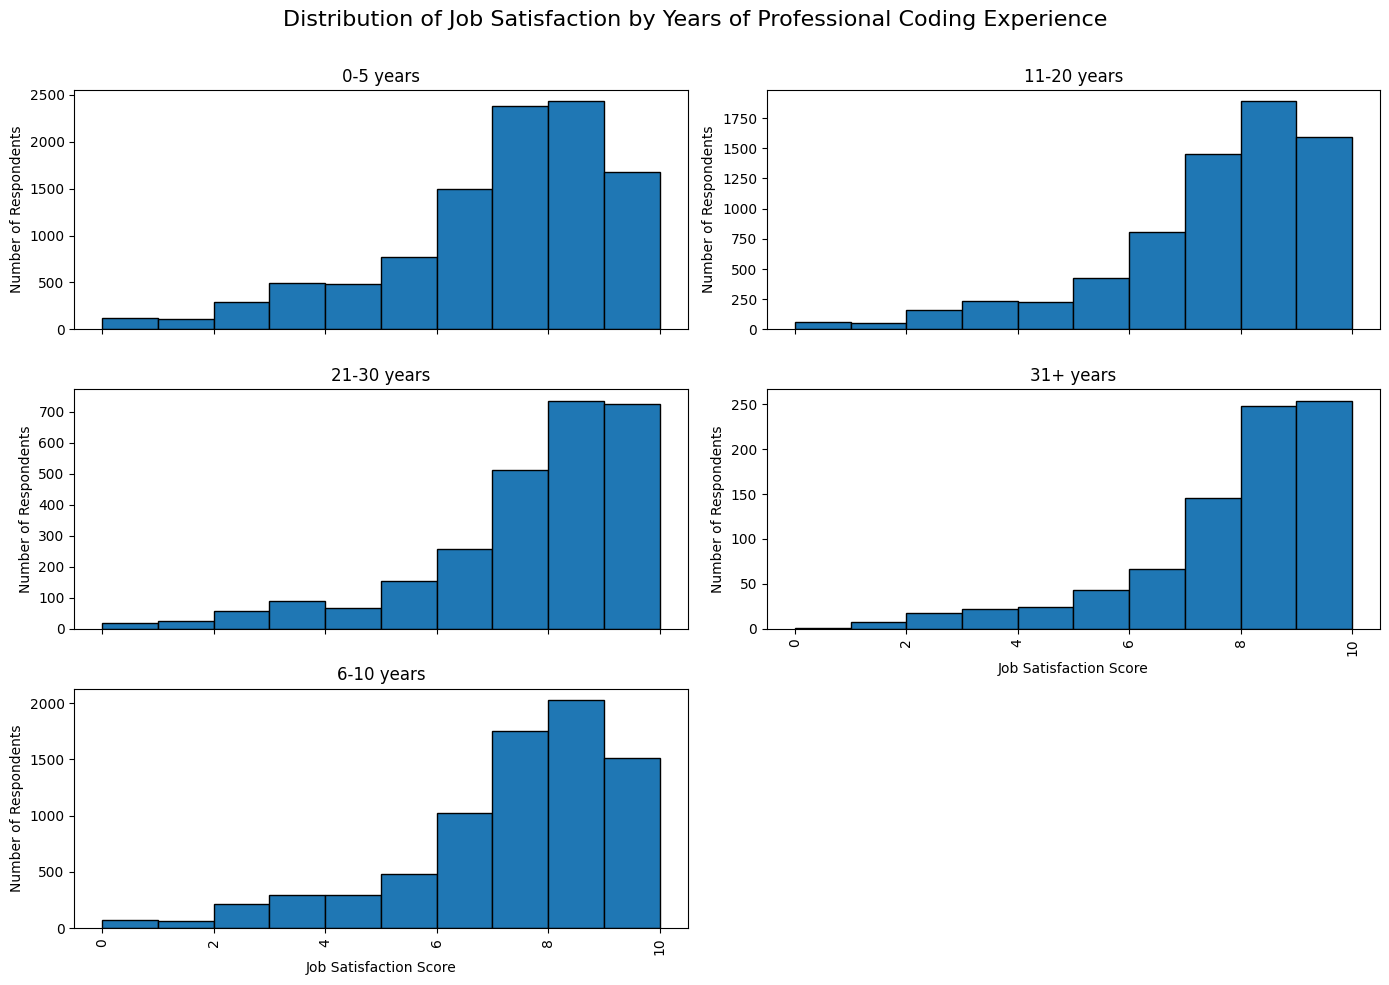

In [82]:
QUERY = """
SELECT YearsCodePro, JobSat
FROM main
WHERE YearsCodePro IS NOT NULL
AND JobSat IS NOT NULL
"""

df_jobsat = pd.read_sql_query(QUERY, conn)

# Replace text values in YearsCodePro
df_jobsat["YearsCodePro"] = df_jobsat["YearsCodePro"].replace({
    "Less than 1 year": 0,
    "More than 50 years": 51
})

# Convert columns to numbers
df_jobsat["YearsCodePro"] = pd.to_numeric(df_jobsat["YearsCodePro"], errors="coerce")
df_jobsat["JobSat"] = pd.to_numeric(df_jobsat["JobSat"], errors="coerce")

# Remove missing values
df_jobsat = df_jobsat.dropna(subset=["YearsCodePro", "JobSat"])

# Create experience groups
def experience_group(years):
    if years <= 5:
        return "0-5 years"
    elif years <= 10:
        return "6-10 years"
    elif years <= 20:
        return "11-20 years"
    elif years <= 30:
        return "21-30 years"
    else:
        return "31+ years"

df_jobsat["ExperienceGroup"] = df_jobsat["YearsCodePro"].apply(experience_group)

# Create histograms of JobSat by experience group
axes = df_jobsat.hist(
    column="JobSat",
    by="ExperienceGroup",
    bins=10,
    figsize=(14, 10),
    edgecolor="black",
    layout=(3, 2),
    sharex=True
)

plt.suptitle("Distribution of Job Satisfaction by Years of Professional Coding Experience", fontsize=16)

for ax in axes.flatten():
    ax.set_xlabel("Job Satisfaction Score")
    ax.set_ylabel("Number of Respondents")

plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
